# Simple/Complex Study: Cell Classification Across Layers

Goal: classify every neuron in the filtered matched dataset as **simple** or **complex**, then study how these two classes are distributed across cortical layers.

Method used in this notebook:
- Use matched V1 excitatory neurons
- Use **Monet2** stimuli only (15 s, 16 sequential direction patches, ~0.94 s each)
- For each neuron × unique Monet2 hash: collect all repeat presentations of that **same** hash, average the response traces (same stimulus → averaging is valid), then compute F1/F0
- F0 = DC component of the uncentered mean trace
- F1 = FFT amplitude at the patch-presentation frequency (bin 16 = 16 patches / 15 s ≈ 1.07 Hz)
- Per-neuron F1/F0 = median across all hash-level estimates
- Label neuron as `simple` if F1/F0 ≥ 1, else `complex`

Crucially, traces from **different hashes are never mixed**: each F1/F0 estimate uses only repeats of one identical stimulus.

In [39]:
%reload_ext autoreload
%autoreload 2

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

warnings.filterwarnings('ignore')
np.random.seed(42)

def find_workspace_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        has_data = (candidate / 'data').exists()
        has_functional = (candidate / 'data' / 'functional').exists()
        has_h5 = (candidate / 'microns.h5').exists()
        if has_data and (has_functional or has_h5):
            return candidate
    raise FileNotFoundError(
        "Could not locate workspace root containing 'data/' and functional files. "
        f"Current working directory: {cwd}"
    )

ROOT = find_workspace_root()
print(f'Workspace root: {ROOT}')

Workspace root: C:\Users\tomma\Desktop\NEUROSCIENCE


In [40]:
# 1) Load filtered matched neurons (V1 excitatory).
REL_DATA_DIR = '../../../data'
cleaner = mic.MicronsDataCleaner(datadir=REL_DATA_DIR, version=1718, download_policy='minimum')
units_match, _ = cleaner.process_nucleus_data(functional_data='match')

matched = fl.filter_neurons(
    units_match,
    tuning='matched',
    cell_type='excitatory_neuron',
    brain_area='V1'
).copy()

unit_id_col = None
for col_name in ['functional_unit_id', 'unit_id', 'index', 'neuron_idx', 'neuron_id']:
    if col_name in matched.columns:
        unit_id_col = col_name
        break

if unit_id_col is None:
    available = ', '.join(matched.columns.astype(str).tolist())
    raise ValueError(
        'No usable neuron index column found in matched table. ' +
        f'Available columns: {available}'
    )

# Exclude L1 to match the previous modeling setup.
matched = matched.dropna(subset=[unit_id_col, 'layer', 'session', 'scan_idx']).copy()
matched['layer'] = matched['layer'].astype(str)
matched = matched[matched['layer'] != 'L1'].copy()

matched['session'] = matched['session'].astype(int)
matched['scan_idx'] = matched['scan_idx'].astype(int)

print(f'Filtered matched rows: {len(matched)}')
print(f'Using unit id column: {unit_id_col}')
print('Layer counts (filtered table):')
print(matched['layer'].value_counts().sort_index().to_string())

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 88769.55it/s]


Filtered matched rows: 13028
Using unit id column: functional_unit_id
Layer counts (filtered table):
layer
L2/3    6340
L4      3941
L5      2269
L6       478


In [41]:
# 2) Open functional data and find shared session/scan keys.
candidate_paths = [
    ROOT / 'data' / 'functional' / 'microns_functional.h5',
    ROOT / 'data' / 'functional' / 'microns_functional.h5.h5',
    ROOT / 'microns.h5',
]
existing = [p.resolve() for p in candidate_paths if p.exists()]
if not existing:
    raise FileNotFoundError('No functional H5 found in expected locations.')

functional_path = existing[0]
funcreader = mic.MicronsFunctionalReader(datadir=REL_DATA_DIR, path=str(functional_path))

session_keys = list(funcreader.f['sessions'].keys())
scan_rows = []
for k in session_keys:
    parts = k.split('_')
    if len(parts) != 2:
        continue
    try:
        scan_rows.append((int(parts[0]), int(parts[1]), k))
    except ValueError:
        continue

available_scan_df = pd.DataFrame(scan_rows, columns=['session', 'scan_idx', 'key'])
available_scan_df = available_scan_df.sort_values(['session', 'scan_idx']).reset_index(drop=True)

matched_scans = matched[['session', 'scan_idx']].drop_duplicates()
scan_candidates = available_scan_df.merge(matched_scans, on=['session', 'scan_idx'], how='inner')

print(f'Using functional file: {functional_path}')
print(f'Available scan keys in functional file: {len(available_scan_df)}')
print(f'Candidate matched session/scan pairs: {len(scan_candidates)}')

Using functional file: C:\Users\tomma\Desktop\NEUROSCIENCE\data\functional\microns_functional.h5
Available scan keys in functional file: 14
Candidate matched session/scan pairs: 14


In [42]:
# 3) Collect full Monet2 response traces, grouped by (neuron, hash).
#
# For each session, find all Monet2 trial indices and their hashes.
# Accumulate the full response trace per trial into:
#   neuron_hash_traces[unit_id][hash] = [trace_repeat_1, trace_repeat_2, ...]
#
# Traces from different hashes are NEVER mixed — only same-hash repeats are pooled.

MIN_TRACE_LEN = 60  # frames

neuron_hash_traces = {}   # unit_id -> {hash: [array, ...]}
neuron_layer       = {}   # unit_id -> layer string
used_trials = 0

for _, row in scan_candidates.iterrows():
    session  = int(row['session'])
    scan_idx = int(row['scan_idx'])
    key      = row['key']

    scan_neurons = matched[(matched['session'] == session) & (matched['scan_idx'] == scan_idx)]
    if scan_neurons.empty:
        continue

    unit_ids_arr = funcreader.f[f'sessions/{key}/meta/unit_ids'][:]
    uid_to_row   = {int(uid): idx for idx, uid in enumerate(unit_ids_arr)}

    # Map trial index -> hash for this session.
    all_hashes = funcreader.get_hashes_by_session(key)  # list, one entry per trial

    for trial_idx, h in enumerate(all_hashes):
        if funcreader.get_video_type(h) != 'Monet2':
            continue

        td = funcreader.get_trial(key, trial_idx)
        if td is None:
            continue

        responses  = np.array(td['responses'])   # (n_units_in_scan, n_frames)
        used_trials += 1

        for _, nr in scan_neurons.iterrows():
            uid   = int(nr[unit_id_col])
            r_idx = uid_to_row.get(uid)
            if r_idx is None or r_idx >= responses.shape[0]:
                continue

            trace = responses[r_idx, :].astype(np.float32)
            trace = trace[np.isfinite(trace)]
            if trace.size < MIN_TRACE_LEN:
                continue

            if uid not in neuron_hash_traces:
                neuron_hash_traces[uid] = {}
                neuron_layer[uid]       = str(nr['layer'])
            neuron_hash_traces[uid].setdefault(h, []).append(trace)

print(f'Monet2 trials processed:           {used_trials}')
print(f'Neurons with ≥1 Monet2 trace:      {len(neuron_hash_traces)}')
n_hashes_per_neuron = [len(v) for v in neuron_hash_traces.values()]
print(f'Mean unique hashes per neuron:     {np.mean(n_hashes_per_neuron):.1f}')
print(f'Max unique hashes per neuron:      {max(n_hashes_per_neuron)}')

Monet2 trials processed:           560
Neurons with ≥1 Monet2 trace:      6548
Mean unique hashes per neuron:     29.0
Max unique hashes per neuron:      80


In [43]:
# 4) Compute F1/F0 per neuron from same-hash-averaged Monet2 traces.
#
# Each Monet2 trial has N_PATCHES=16 direction patches over 15 s.
# Patch presentation frequency = 16/15 ≈ 1.07 Hz.
# For a trace of length T frames sampled over 15 s:
#   FFT bin k corresponds to frequency k/15 Hz
#   → F1 bin = 16  (since 16/15 Hz × 15 s = 16)
#
# Per neuron: for each unique hash, average its repeat traces, compute F1/F0.
# Final F1/F0 = median over all hash-level estimates (robust to noisy hashes).
# Different hashes are NEVER averaged together.

N_PATCHES   = 16   # direction patches per Monet2 trial → F1 bin
F1F0_THRESH = 1.0  # standard simple/complex threshold

def f1_f0_monet(trace: np.ndarray, f1_bin: int) -> float:
    x = np.asarray(trace, dtype=np.float32).ravel()
    if x.size < 2 or not np.all(np.isfinite(x)):
        return np.nan
    spec_raw = np.abs(np.fft.rfft(x))
    f0 = float(spec_raw[0])
    xc = x - x.mean()
    spec_c = np.abs(np.fft.rfft(xc))
    if f1_bin >= spec_c.size:
        return np.nan
    f1 = float(spec_c[f1_bin])
    return f1 / (f0 + 1e-8)

rows = []

for uid, hash_traces in neuron_hash_traces.items():
    hash_ratios = []

    for h, traces in hash_traces.items():
        if len(traces) == 0:
            continue
        # Average only repeats of the SAME hash (same stimulus).
        min_len    = min(t.size for t in traces)
        mean_trace = np.vstack([t[:min_len] for t in traces]).mean(axis=0)

        # F1 bin = N_PATCHES (valid when trace covers exactly one full trial).
        ratio = f1_f0_monet(mean_trace, f1_bin=N_PATCHES)
        if np.isfinite(ratio):
            hash_ratios.append(ratio)

    if len(hash_ratios) == 0:
        continue

    median_ratio = float(np.median(hash_ratios))
    rows.append({
        'unit_id':        uid,
        'layer':          neuron_layer[uid],
        'n_hashes':       len(hash_ratios),
        'f1_f0_ratio':    median_ratio,
        'cell_type_sc':   'simple' if median_ratio >= F1F0_THRESH else 'complex',
    })

cells_df = pd.DataFrame(rows).sort_values(['layer', 'unit_id']).reset_index(drop=True)

if cells_df.empty:
    raise ValueError('No classifiable cells. Check Monet2 trial coverage.')

print(f'Classified cells:     {len(cells_df)}')
print(f'F1/F0 threshold used: {F1F0_THRESH}')
print()
print('Overall simple/complex counts:')
print(cells_df['cell_type_sc'].value_counts().to_string())
print()
print('F1/F0 quantiles:')
print(cells_df['f1_f0_ratio'].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).round(4).to_string())
cells_df.head()

Classified cells:     6548
F1/F0 threshold used: 1.0

Overall simple/complex counts:
cell_type_sc
complex    6548

F1/F0 quantiles:
0.05    0.1736
0.25    0.2174
0.50    0.2534
0.75    0.2961
0.95    0.3936


,unit_id,layer,n_hashes,f1_f0_ratio,cell_type_sc
0,662,L2/3,20,0.202644,complex
1,671,L2/3,20,0.520574,complex
2,682,L2/3,20,0.140485,complex
3,686,L2/3,20,0.299197,complex
4,690,L2/3,20,0.281263,complex


In [44]:
# 5) Layer-wise counts and proportions.
layer_type_counts = (
    cells_df.groupby(['layer', 'cell_type_sc'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

for col in ['simple', 'complex']:
    if col not in layer_type_counts.columns:
        layer_type_counts[col] = 0

layer_type_counts = layer_type_counts[['simple', 'complex']]
layer_type_props = layer_type_counts.div(layer_type_counts.sum(axis=1), axis=0)

print('Counts by layer:')
display(layer_type_counts)

print('Proportions by layer:')
display((100 * layer_type_props).round(1))

Counts by layer:


cell_type_sc,simple,complex
layer,,
L2/3,0,2704
L4,0,2072
L5,0,1425
L6,0,347


Proportions by layer:


cell_type_sc,simple,complex
layer,,
L2/3,0.0,100.0
L4,0.0,100.0
L5,0.0,100.0
L6,0.0,100.0


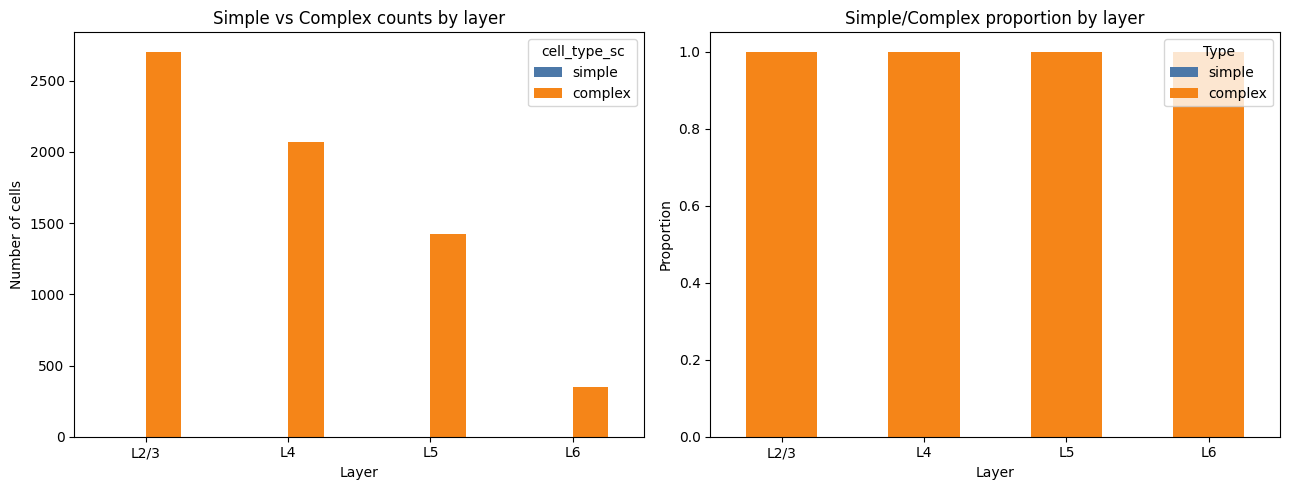

In [45]:
# 6) Visualize distribution of simple/complex cells across layers.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

layer_type_counts.plot(kind='bar', ax=axes[0], color=['#4C78A8', '#F58518'])
axes[0].set_title('Simple vs Complex counts by layer')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Number of cells')
axes[0].tick_params(axis='x', rotation=0)

layer_type_props.plot(kind='bar', stacked=True, ax=axes[1], color=['#4C78A8', '#F58518'])
axes[1].set_title('Simple/Complex proportion by layer')
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Type', loc='upper right')

plt.tight_layout()
plt.show()

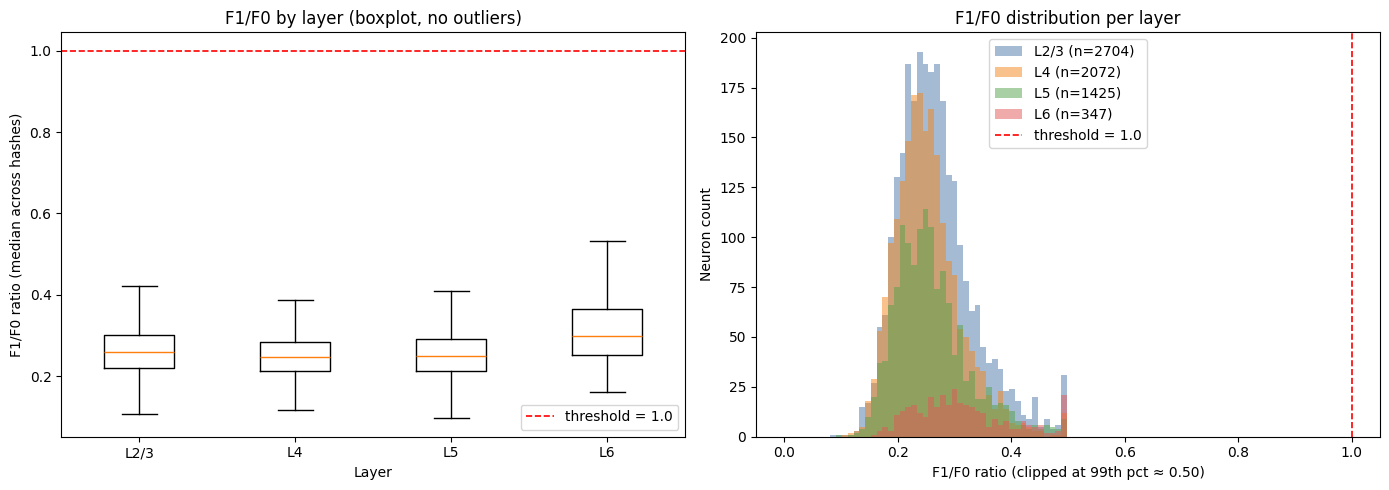

In [46]:
# 7) F1/F0 distribution across layers: boxplot + per-layer histograms.
layers = sorted(cells_df['layer'].unique())
colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Boxplot ---
box_data = [cells_df.loc[cells_df['layer'] == ly, 'f1_f0_ratio'].values for ly in layers]
axes[0].boxplot(box_data, tick_labels=layers, showfliers=False)
axes[0].axhline(F1F0_THRESH, color='red', linestyle='--', linewidth=1.2, label=f'threshold = {F1F0_THRESH}')
axes[0].set_title('F1/F0 by layer (boxplot, no outliers)')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('F1/F0 ratio (median across hashes)')
axes[0].legend()

# --- Overlaid histograms (one per layer) ---
clip_val = cells_df['f1_f0_ratio'].quantile(0.99)  # clip extreme tail for readability
bins = np.linspace(0, clip_val, 50)
for ly, col in zip(layers, colors):
    vals = cells_df.loc[cells_df['layer'] == ly, 'f1_f0_ratio'].clip(upper=clip_val).values
    axes[1].hist(vals, bins=bins, alpha=0.5, color=col, label=f'{ly} (n={len(vals)})')
axes[1].axvline(F1F0_THRESH, color='red', linestyle='--', linewidth=1.2, label=f'threshold = {F1F0_THRESH}')
axes[1].set_title('F1/F0 distribution per layer')
axes[1].set_xlabel(f'F1/F0 ratio (clipped at 99th pct ≈ {clip_val:.2f})')
axes[1].set_ylabel('Neuron count')
axes[1].legend()

plt.tight_layout()
plt.show()

## Notes

- This labels each neuron once, using its trial-averaged normalized trace.
- If you want stricter definitions, you can swap in a stimulus-phase-aware computation of $F1/F0$.
- To compare with your previous classification notebook, keep the same filtering assumptions (area, cell type, layer exclusions).

In [47]:
# Debug: coverage summary.
matched_units    = set(matched[unit_id_col].astype(int).tolist())
monet_units      = set(neuron_hash_traces.keys())
classified_units = set(cells_df['unit_id'].tolist())

print(f'Unique matched units:                {len(matched_units)}')
print(f'Units with ≥1 Monet2 trace:          {len(monet_units)}')
print(f'Units classified:                    {len(classified_units)}')
print(f'Units with no Monet2 coverage:       {len(matched_units - monet_units)}')
print()
print(f'Median hashes per classified neuron: {cells_df["n_hashes"].median():.0f}')
print(f'Min hashes per classified neuron:    {cells_df["n_hashes"].min()}')

Unique matched units:                6692
Units with ≥1 Monet2 trace:          6548
Units classified:                    6548
Units with no Monet2 coverage:       144

Median hashes per classified neuron: 20
Min hashes per classified neuron:    20


## F1/F0 Distribution and Per-Hash Diagnostics

This section shows:
- Overall and per-layer F1/F0 distributions with the simple/complex threshold
- The spread of per-hash F1/F0 estimates for a sample of neurons (to assess reliability)

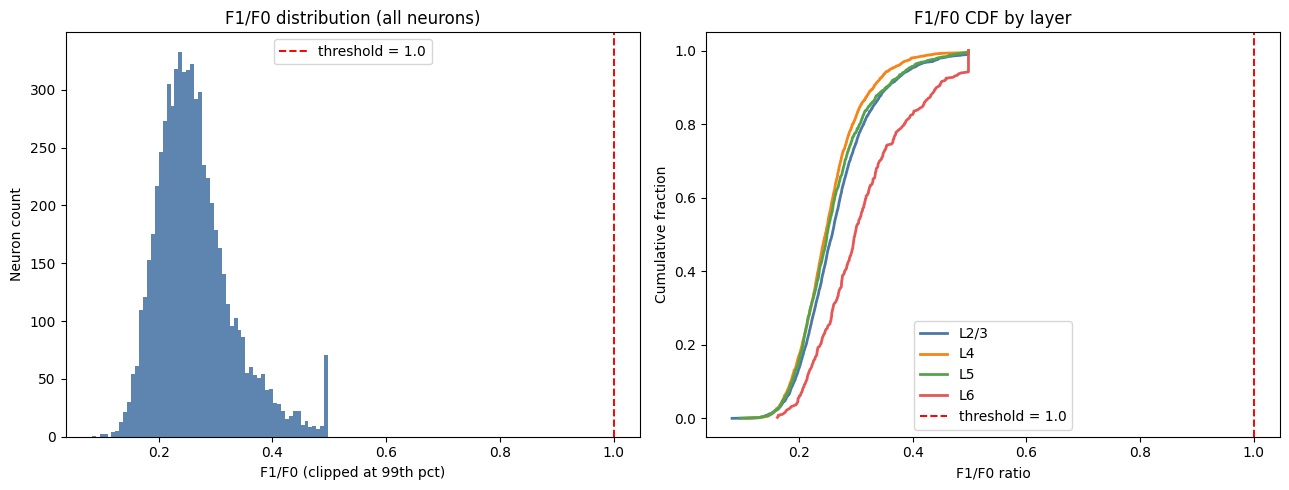

Simple cell fraction by layer:
  L2/3: 0.0%  (n=2704)
  L4: 0.0%  (n=2072)
  L5: 0.0%  (n=1425)
  L6: 0.0%  (n=347)


In [48]:
# 8) Overall F1/F0 distribution + per-layer CDF.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

clip_val = cells_df['f1_f0_ratio'].quantile(0.99)

# Overall histogram.
axes[0].hist(cells_df['f1_f0_ratio'].clip(upper=clip_val), bins=60, color='#4C78A8', alpha=0.9)
axes[0].axvline(F1F0_THRESH, color='red', linestyle='--', linewidth=1.4, label=f'threshold = {F1F0_THRESH}')
axes[0].set_title('F1/F0 distribution (all neurons)')
axes[0].set_xlabel(f'F1/F0 (clipped at 99th pct)')
axes[0].set_ylabel('Neuron count')
axes[0].legend()

# CDF by layer.
layers = sorted(cells_df['layer'].unique())
colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756']
for ly, col in zip(layers, colors):
    vals = np.sort(cells_df.loc[cells_df['layer'] == ly, 'f1_f0_ratio'].values)
    cdf  = np.arange(1, len(vals) + 1) / len(vals)
    axes[1].plot(np.clip(vals, 0, clip_val), cdf, color=col, linewidth=2, label=ly)
axes[1].axvline(F1F0_THRESH, color='red', linestyle='--', linewidth=1.4, label=f'threshold = {F1F0_THRESH}')
axes[1].set_title('F1/F0 CDF by layer')
axes[1].set_xlabel('F1/F0 ratio')
axes[1].set_ylabel('Cumulative fraction')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Simple cell fraction by layer:')
for ly in layers:
    sub  = cells_df[cells_df['layer'] == ly]
    frac = (sub['cell_type_sc'] == 'simple').mean()
    print(f'  {ly}: {100*frac:.1f}%  (n={len(sub)})')

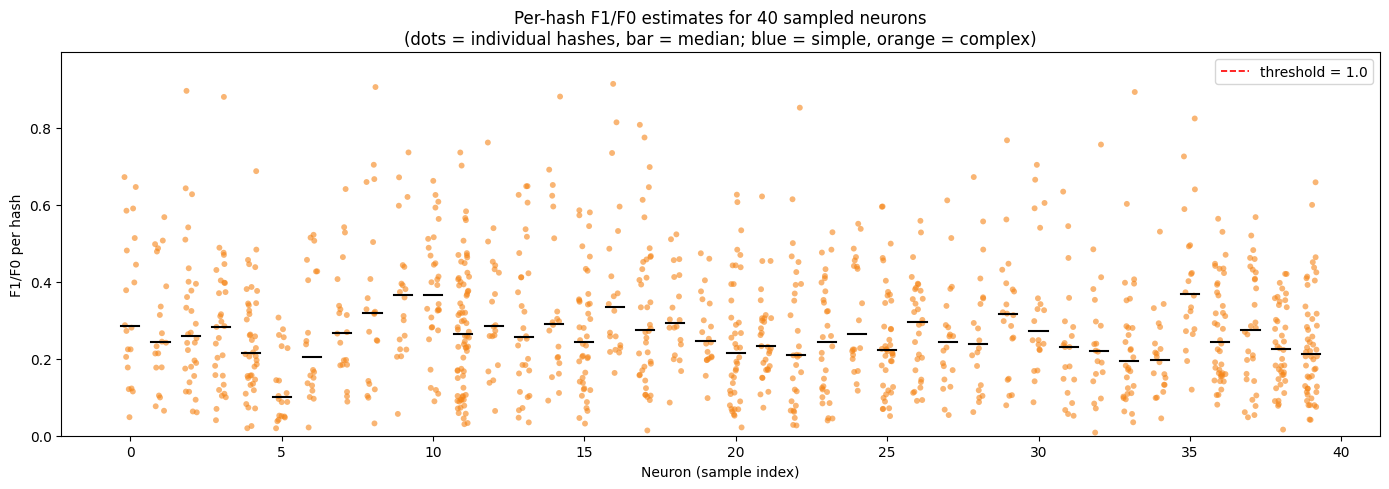

In [49]:
# 9) Per-hash F1/F0 spread: how consistent are estimates within a neuron?
#    For a random sample of neurons, show all per-hash F1/F0 values as a strip plot.
import random

random.seed(0)
sample_ids = random.sample(list(neuron_hash_traces.keys()), min(40, len(neuron_hash_traces)))

fig, ax = plt.subplots(figsize=(14, 5))

for i, uid in enumerate(sample_ids):
    hash_ratios = []
    for h, traces in neuron_hash_traces[uid].items():
        if len(traces) == 0:
            continue
        min_len    = min(t.size for t in traces)
        mean_trace = np.vstack([t[:min_len] for t in traces]).mean(axis=0)
        r = f1_f0_monet(mean_trace, f1_bin=N_PATCHES)
        if np.isfinite(r):
            hash_ratios.append(r)
    if not hash_ratios:
        continue
    jitter = np.random.uniform(-0.2, 0.2, size=len(hash_ratios))
    sc = cells_df.loc[cells_df['unit_id'] == uid, 'cell_type_sc'].iloc[0]
    col = '#4C78A8' if sc == 'simple' else '#F58518'
    ax.scatter([i] * len(hash_ratios) + jitter, hash_ratios, s=18, color=col, alpha=0.6, edgecolors='none')
    ax.plot([i - 0.3, i + 0.3], [np.median(hash_ratios)] * 2, color='black', linewidth=1.5)

ax.axhline(F1F0_THRESH, color='red', linestyle='--', linewidth=1.2, label=f'threshold = {F1F0_THRESH}')
ax.set_ylim(0, min(cells_df['f1_f0_ratio'].quantile(0.99) * 2, ax.get_ylim()[1]))
ax.set_title('Per-hash F1/F0 estimates for 40 sampled neurons\n(dots = individual hashes, bar = median; blue = simple, orange = complex)')
ax.set_xlabel('Neuron (sample index)')
ax.set_ylabel('F1/F0 per hash')
ax.legend()
plt.tight_layout()
plt.show()

---

## Part 2: DMI Classification (Direction Modulation Index)

For each neuron, extract the mean response per direction window across all Monet2 trials, then compute:

$$\text{DMI} = \frac{R_{\max} - \bar{R}}{R_{\max} + \bar{R}}$$

- **DMI ≈ 0** → flat tuning, responds to all directions equally → complex-like  
- **DMI ≈ 1** → strong preferred direction, suppressed elsewhere → simple-like  
- Threshold at **0.33** (equivalent to R_max = 2 × R_mean, standard DSI cutoff)

Note: unlike F1/F0, DMI averages across different Monet2 hashes for each direction label — this is valid because DMI only cares about the direction label, not the specific stimulus identity.

In [50]:
# DMI-4) Collect Monet2 direction-aligned responses for the DMI metric.
#
# For each direction patch in each Monet2 trial, extract the mean neural response
# in a window [onset + lag, onset + lag + window] and store it per neuron per direction.
# Traces from DIFFERENT hashes are pooled here because DMI only uses the mean response
# per direction across all observations — the stimulus identity does not matter for DMI,
# only the direction label does.

RESPONSE_ONSET_LAG = 0.05
RESPONSE_WINDOW    = 0.80

neuron_dir_responses = {}   # unit_id -> {'layer': str, 'dirs': {deg: [mean_resp, ...]}}

for _, row in scan_candidates.iterrows():
    session  = int(row['session'])
    scan_idx = int(row['scan_idx'])
    key      = row['key']

    scan_neurons = matched[(matched['session'] == session) & (matched['scan_idx'] == scan_idx)]
    if scan_neurons.empty:
        continue

    unit_ids_arr = funcreader.f[f'sessions/{key}/meta/unit_ids'][:]
    uid_to_row   = {int(uid): idx for idx, uid in enumerate(unit_ids_arr)}
    all_hashes   = funcreader.get_hashes_by_session(key)

    for trial_idx, h in enumerate(all_hashes):
        if funcreader.get_video_type(h) != 'Monet2':
            continue
        td = funcreader.get_trial(key, trial_idx)
        if td is None:
            continue

        vdata      = funcreader.get_video_data(h)
        directions = np.array(vdata['directions']).ravel()
        onsets     = np.array(vdata['onsets']).ravel()
        stim_times = np.array(td['stim_times'])
        responses  = np.array(td['responses'])
        t0         = stim_times[0]

        for direction, onset in zip(directions, onsets):
            win_start  = t0 + onset + RESPONSE_ONSET_LAG
            win_end    = win_start + RESPONSE_WINDOW
            frame_idxs = np.where((stim_times >= win_start) & (stim_times < win_end))[0]
            if frame_idxs.size == 0:
                continue
            mean_all = responses[:, frame_idxs].mean(axis=1)

            for _, nr in scan_neurons.iterrows():
                uid   = int(nr[unit_id_col])
                r_idx = uid_to_row.get(uid)
                if r_idx is None or r_idx >= len(mean_all):
                    continue
                mean_r = float(mean_all[r_idx])
                if not np.isfinite(mean_r):
                    continue
                if uid not in neuron_dir_responses:
                    neuron_dir_responses[uid] = {'layer': str(nr['layer']), 'dirs': {}}
                neuron_dir_responses[uid]['dirs'].setdefault(direction, []).append(mean_r)

print(f'Neurons with direction responses: {len(neuron_dir_responses)}')
n_dirs = [len(v["dirs"]) for v in neuron_dir_responses.values()]
print(f'Mean directions covered: {np.mean(n_dirs):.1f}  |  neurons with all 16: {sum(1 for n in n_dirs if n == 16)}')

Neurons with direction responses: 6548
Mean directions covered: 16.0  |  neurons with all 16: 6548


In [51]:
# DMI-5) Compute Direction Modulation Index and classify each neuron.
MIN_DIRS_REQUIRED = 8
DMI_THRESHOLD     = 0.33

def compute_dmi(dirs: dict) -> tuple:
    dir_means = {d: max(0.0, float(np.nanmean(v))) for d, v in dirs.items() if np.isfinite(np.nanmean(v))}
    if len(dir_means) < MIN_DIRS_REQUIRED:
        return np.nan, np.nan, np.nan, len(dir_means)
    arr    = np.array(list(dir_means.values()))
    r_max  = float(arr.max())
    r_mean = float(arr.mean())
    if r_max + r_mean < 1e-8:
        return 0.0, r_max, r_mean, len(dir_means)
    return (r_max - r_mean) / (r_max + r_mean), r_max, r_mean, len(dir_means)

rows_dmi = []
for uid, info in neuron_dir_responses.items():
    dmi, r_max, r_mean, n_dirs = compute_dmi(info['dirs'])
    if not np.isfinite(dmi):
        continue
    rows_dmi.append({
        'unit_id':      uid,
        'layer':        info['layer'],
        'n_dirs':       n_dirs,
        'dmi':          dmi,
        'r_max':        r_max,
        'r_mean':       r_mean,
        'cell_type_sc': 'simple' if dmi >= DMI_THRESHOLD else 'complex',
    })

cells_df_dmi = pd.DataFrame(rows_dmi).sort_values(['layer', 'unit_id']).reset_index(drop=True)
if cells_df_dmi.empty:
    raise ValueError('No classifiable cells for DMI. Check Monet2 direction coverage.')

print(f'DMI classified cells:  {len(cells_df_dmi)}')
print(f'DMI threshold:         {DMI_THRESHOLD}')
print()
print('Overall simple/complex counts (DMI):')
print(cells_df_dmi['cell_type_sc'].value_counts().to_string())
print()
print('DMI quantiles:')
print(cells_df_dmi['dmi'].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).round(3).to_string())
cells_df_dmi.head()

DMI classified cells:  6548
DMI threshold:         0.33

Overall simple/complex counts (DMI):
cell_type_sc
simple     3280
complex    3268

DMI quantiles:
0.05    0.180
0.25    0.261
0.50    0.330
0.75    0.409
0.95    0.524


,unit_id,layer,n_dirs,dmi,r_max,r_mean,cell_type_sc
0,662,L2/3,16,0.496854,19.039170,6.399744,simple
1,671,L2/3,16,0.400587,1.550810,0.663705,simple
2,682,L2/3,16,0.173206,1.085055,0.764671,complex
3,686,L2/3,16,0.336518,4.068987,2.019952,simple
4,690,L2/3,16,0.406208,1.208300,0.510222,simple


DMI — counts by layer:


cell_type_sc,simple,complex
layer,,
L2/3,1455,1249
L4,952,1120
L5,712,713
L6,161,186


DMI — proportions by layer:


cell_type_sc,simple,complex
layer,,
L2/3,53.8,46.2
L4,45.9,54.1
L5,50.0,50.0
L6,46.4,53.6


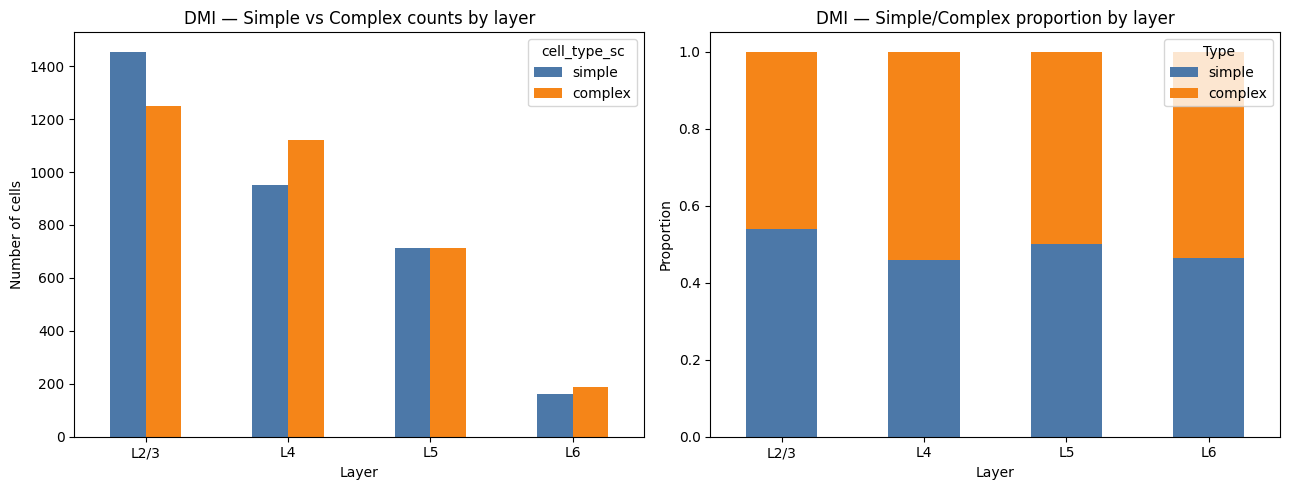

In [52]:
# DMI-6) Layer-wise DMI counts and proportions.
layer_type_counts_dmi = (
    cells_df_dmi.groupby(['layer', 'cell_type_sc'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
for col in ['simple', 'complex']:
    if col not in layer_type_counts_dmi.columns:
        layer_type_counts_dmi[col] = 0
layer_type_counts_dmi  = layer_type_counts_dmi[['simple', 'complex']]
layer_type_props_dmi   = layer_type_counts_dmi.div(layer_type_counts_dmi.sum(axis=1), axis=0)

print('DMI — counts by layer:')
display(layer_type_counts_dmi)
print('DMI — proportions by layer:')
display((100 * layer_type_props_dmi).round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
layer_type_counts_dmi.plot(kind='bar', ax=axes[0], color=['#4C78A8', '#F58518'])
axes[0].set_title('DMI — Simple vs Complex counts by layer')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Number of cells')
axes[0].tick_params(axis='x', rotation=0)

layer_type_props_dmi.plot(kind='bar', stacked=True, ax=axes[1], color=['#4C78A8', '#F58518'])
axes[1].set_title('DMI — Simple/Complex proportion by layer')
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Type', loc='upper right')
plt.tight_layout()
plt.show()

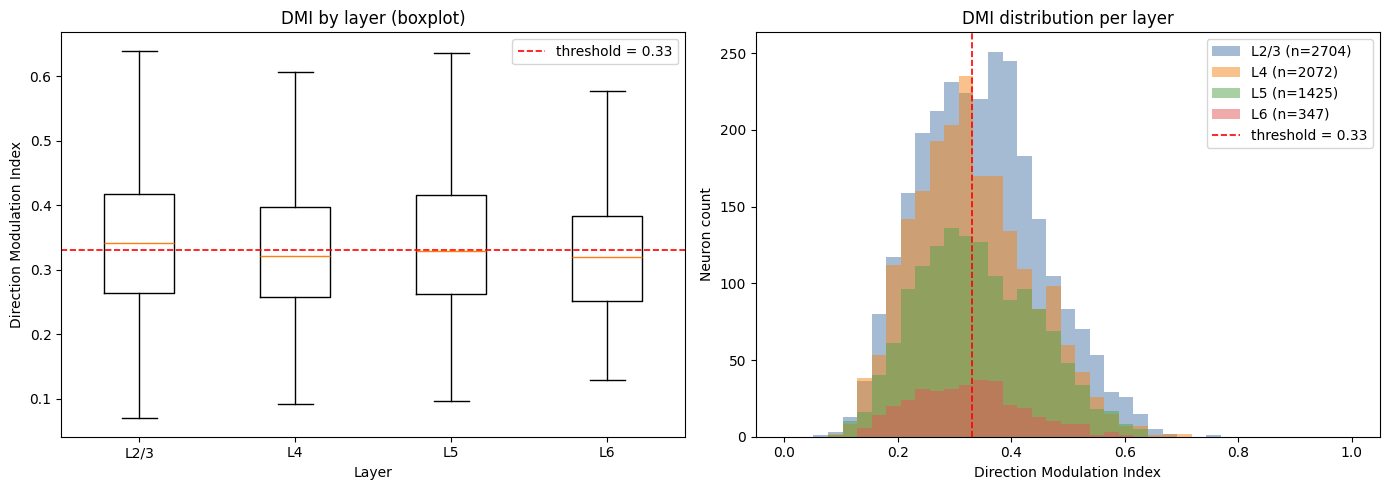

In [53]:
# DMI-7) DMI distribution across layers: boxplot + per-layer histograms.
layers_dmi = sorted(cells_df_dmi['layer'].unique())
colors_dmi = ['#4C78A8', '#F58518', '#54A24B', '#E45756']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

box_data_dmi = [cells_df_dmi.loc[cells_df_dmi['layer'] == ly, 'dmi'].values for ly in layers_dmi]
axes[0].boxplot(box_data_dmi, tick_labels=layers_dmi, showfliers=False)
axes[0].axhline(DMI_THRESHOLD, color='red', linestyle='--', linewidth=1.2, label=f'threshold = {DMI_THRESHOLD}')
axes[0].set_title('DMI by layer (boxplot)')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Direction Modulation Index')
axes[0].legend()

bins_dmi = np.linspace(0, 1, 40)
for ly, col in zip(layers_dmi, colors_dmi):
    vals = cells_df_dmi.loc[cells_df_dmi['layer'] == ly, 'dmi'].values
    axes[1].hist(vals, bins=bins_dmi, alpha=0.5, color=col, label=f'{ly} (n={len(vals)})')
axes[1].axvline(DMI_THRESHOLD, color='red', linestyle='--', linewidth=1.2, label=f'threshold = {DMI_THRESHOLD}')
axes[1].set_title('DMI distribution per layer')
axes[1].set_xlabel('Direction Modulation Index')
axes[1].set_ylabel('Neuron count')
axes[1].legend()

plt.tight_layout()
plt.show()

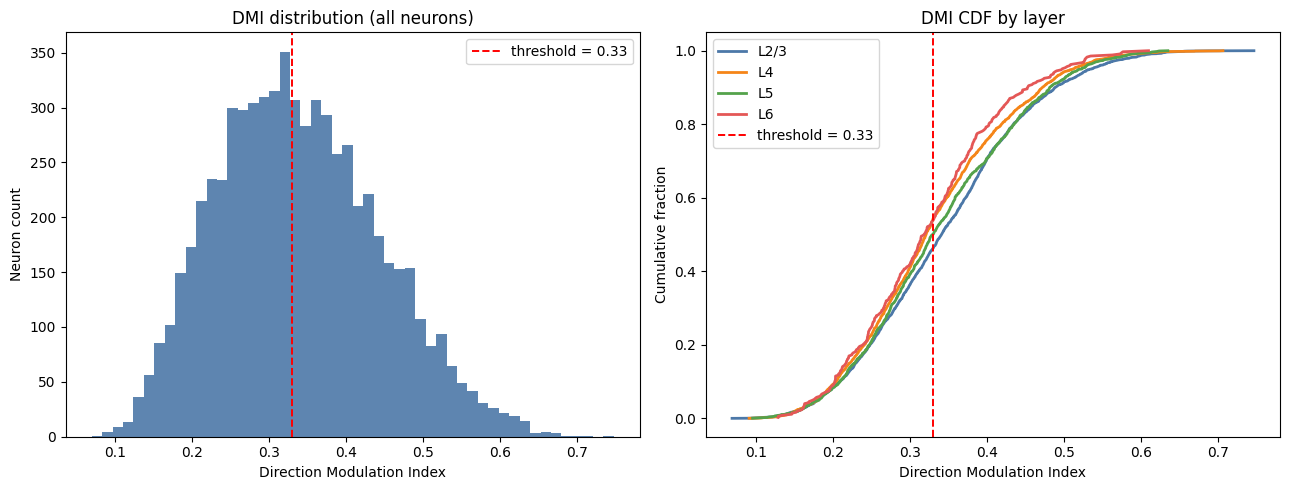

DMI — simple cell fraction by layer:
  L2/3: 53.8%  (n=2704)
  L4: 45.9%  (n=2072)
  L5: 50.0%  (n=1425)
  L6: 46.4%  (n=347)


In [54]:
# DMI-8) DMI distribution: overall histogram + per-layer CDF.
layers_dmi = sorted(cells_df_dmi['layer'].unique())
colors_dmi = ['#4C78A8', '#F58518', '#54A24B', '#E45756']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(cells_df_dmi['dmi'], bins=50, color='#4C78A8', alpha=0.9)
axes[0].axvline(DMI_THRESHOLD, color='red', linestyle='--', linewidth=1.4, label=f'threshold = {DMI_THRESHOLD}')
axes[0].set_title('DMI distribution (all neurons)')
axes[0].set_xlabel('Direction Modulation Index')
axes[0].set_ylabel('Neuron count')
axes[0].legend()

for ly, col in zip(layers_dmi, colors_dmi):
    vals = np.sort(cells_df_dmi.loc[cells_df_dmi['layer'] == ly, 'dmi'].values)
    cdf  = np.arange(1, len(vals) + 1) / len(vals)
    axes[1].plot(vals, cdf, color=col, linewidth=2, label=ly)
axes[1].axvline(DMI_THRESHOLD, color='red', linestyle='--', linewidth=1.4, label=f'threshold = {DMI_THRESHOLD}')
axes[1].set_title('DMI CDF by layer')
axes[1].set_xlabel('Direction Modulation Index')
axes[1].set_ylabel('Cumulative fraction')
axes[1].legend()

plt.tight_layout()
plt.show()

print('DMI — simple cell fraction by layer:')
for ly in layers_dmi:
    sub  = cells_df_dmi[cells_df_dmi['layer'] == ly]
    frac = (sub['cell_type_sc'] == 'simple').mean()
    print(f'  {ly}: {100*frac:.1f}%  (n={len(sub)})')

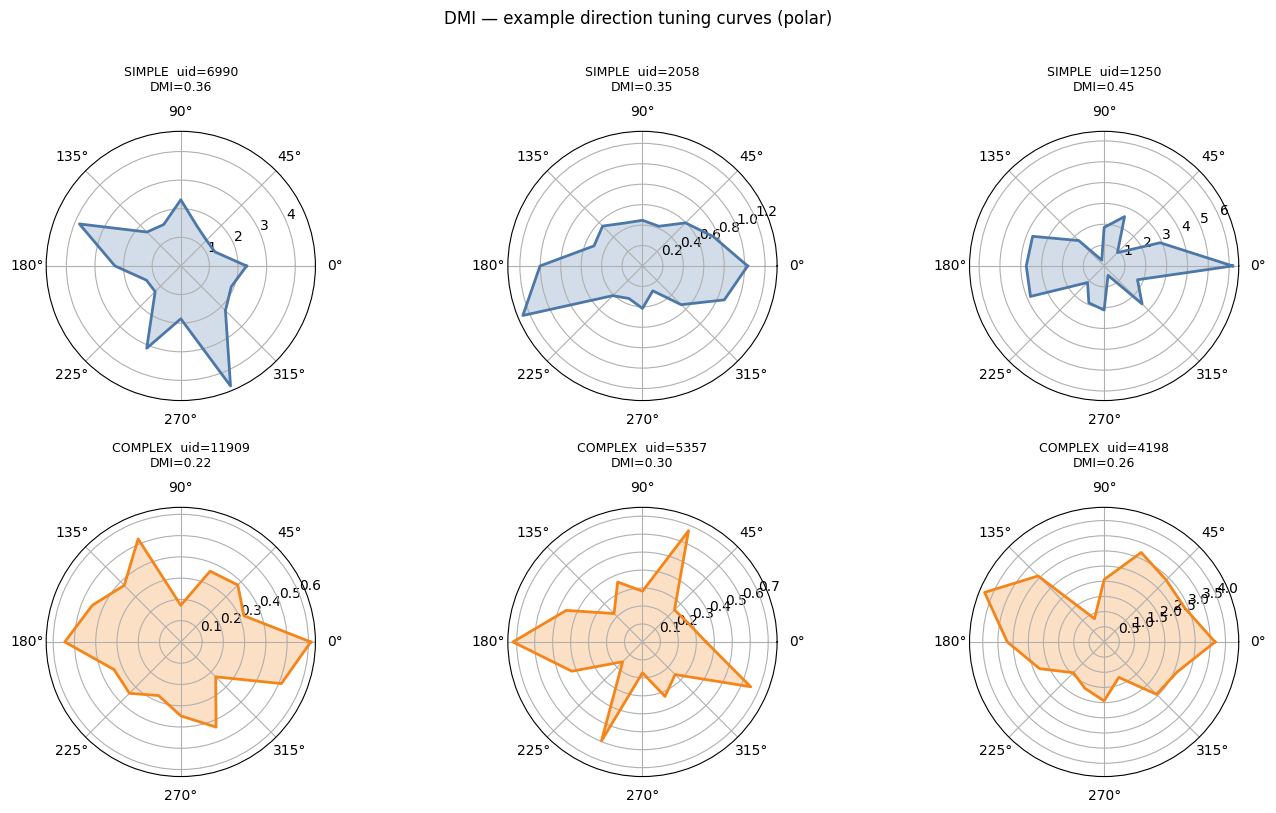

In [55]:
# DMI-9) Example polar direction tuning curves: simple vs complex neurons.
import random as _random
_random.seed(42)

simple_ids_dmi  = cells_df_dmi.loc[cells_df_dmi['cell_type_sc'] == 'simple',  'unit_id'].tolist()
complex_ids_dmi = cells_df_dmi.loc[cells_df_dmi['cell_type_sc'] == 'complex', 'unit_id'].tolist()

examples_dmi = (
    [('simple',  uid) for uid in _random.sample(simple_ids_dmi,  min(3, len(simple_ids_dmi)))] +
    [('complex', uid) for uid in _random.sample(complex_ids_dmi, min(3, len(complex_ids_dmi)))]
)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), subplot_kw=dict(projection='polar'))

for ax, (sc_type, uid) in zip(axes.flat, examples_dmi):
    dirs_raw  = neuron_dir_responses[uid]['dirs']
    dir_means = {d: max(0.0, float(np.nanmean(v))) for d, v in dirs_raw.items() if np.isfinite(np.nanmean(v))}
    s_dirs    = sorted(dir_means.keys())
    angles    = np.deg2rad(s_dirs + [s_dirs[0]])
    values    = [dir_means[d] for d in s_dirs] + [dir_means[s_dirs[0]]]
    dmi_val   = cells_df_dmi.loc[cells_df_dmi['unit_id'] == uid, 'dmi'].iloc[0]
    col       = '#4C78A8' if sc_type == 'simple' else '#F58518'
    ax.plot(angles, values, color=col, linewidth=2)
    ax.fill(angles, values, color=col, alpha=0.25)
    ax.set_title(f'{sc_type.upper()}  uid={uid}\nDMI={dmi_val:.2f}', fontsize=9, pad=10)

plt.suptitle('DMI — example direction tuning curves (polar)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()